
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** (laboratorio 4)

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [4]:
#librerias
import matplotlib.pyplot as plt
import numpy as np

### Punto 1 ###

In [3]:
#función para el metodo de jacobi de diferencias finitas con tolerancia 
def Laplace_fdmtol(V0, tol=0.01):  
    Nmax = V0.shape[0]
    dif = 1.0
    iteraciones = 0
    V1 = V0.copy()

    while dif > tol:
        V = V1.copy()  

        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                V[i, j] = 0.25 * (V1[i + 1, j] + V1[i - 1, j] + V1[i, j + 1] + V1[i, j - 1])

        dif = np.max(np.abs(V - V1))
        iteraciones += 1
        V1 = V

    return V1, iteraciones

#función para graficar 
def grid (V0,x,y):
    V = V0.copy()
    X , Y = np.meshgrid(x,y)
    Z = V[X,Y]
    return X,Y,Z

#función para la solucion analitica con tolerancia 

def Laplace_analitca(v0, tol, L):
    xcoor = np.linspace(0, L, 100)
    ycoor = np.linspace(0, L, 100)
    n = 1
    dif = 1
    inte = 0

    X, Y = np.meshgrid(xcoor, ycoor)
    sol = np.zeros_like(X)
    
    while dif > tol:
        term = (4*v0/(n*np.pi))*np.sin(n*np.pi*X/L)*np.sinh(n*np.pi*(L-Y)/L)/np.sinh(n*np.pi)
        dif = np.max(np.abs(term - sol))
        sol += term
        n += 2
        inte += 1
        
    return sol, X, Y , inte

#funcion de solución analitica por tolerancia con una aproximacion en los sinh debido a su divergencia en valores grandes de n 
def Laplace_analitca2(v0, tol, L, N):
    xcoor = np.linspace(0, L, N)
    ycoor = np.linspace(0, L, N)
    n = 1
    dif = 1.0
    inte = 0

    X, Y = np.meshgrid(xcoor, ycoor)
    sol = np.zeros_like(X)

    while dif > tol:
        term = (
            (4 * v0 / (n * np.pi))
            * np.sin(n * np.pi * X / L)
            * np.exp(-n * np.pi * Y / L)
        )
        dif = np.max(np.abs(term))
        sol += term
        n += 2
        inte += 1
        if inte > 5000:
            break

    return sol, X, Y, inte

**Justificación:** Modifique la función original de manera que ahora uno de los parametros se la tolerancia en vez de el numero de interacciones deseado, y que este fuera el criterio para realizar el ciclo, como en el codigo original se toma el valor de Nmax y se crea una copia de la matriz original, ademas inicializamos dos variables la de dif que nos va a permitir cuantizar la diferencia entre cada paso del ciclo y la cantidad de interacciones uqe nos va a ayudar en caso de querer saber cuantas veces se realizo el ciclo, una vez realizado el metodo de jacobi se calcula diferencia entre pasos antes y despues de realizado el ciclo, y se toma el valor maximo de la diferencia en valor absoluto y este sera el nuevo valor de comparacion, el ciclo para cuando esta diferencia se vuelve menor que el valor de tolerancia y regresa la ultima matriz calculada y el numero de interaciones.

In [5]:
# Definimos los parametros de divisiones y la tolerancia que usaremos.
div = 100
tol = 1e-3

#Creamos la matriz con la informacion inicial 
v_ini = np.zeros((div,div), float)
for k in range (div):
    v_ini[k,0] = 100 

#Ejecutamos la funcion 
V , inte = Laplace_fdmtol(v_ini, tol)

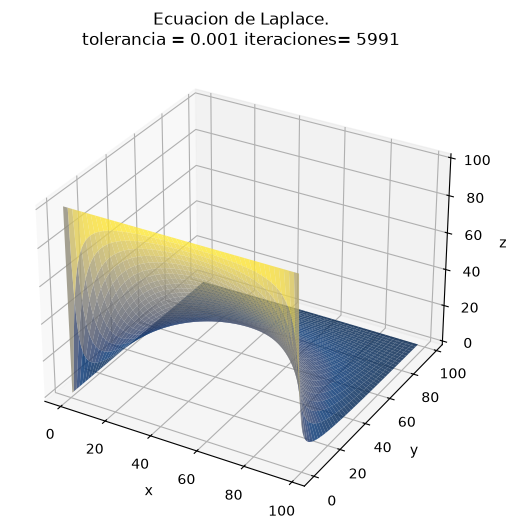

In [6]:
#Creamos la informacion para el grafico 3D
x = np.arange(0, div-1, 1)
y= x
X,Y,Z = grid (V, x, y)

#Grafico en 3D
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cividis', alpha=0.8)
ax.set_title(f'Ecuacion de Laplace.\ntolerancia = {tol} iteraciones= {inte}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

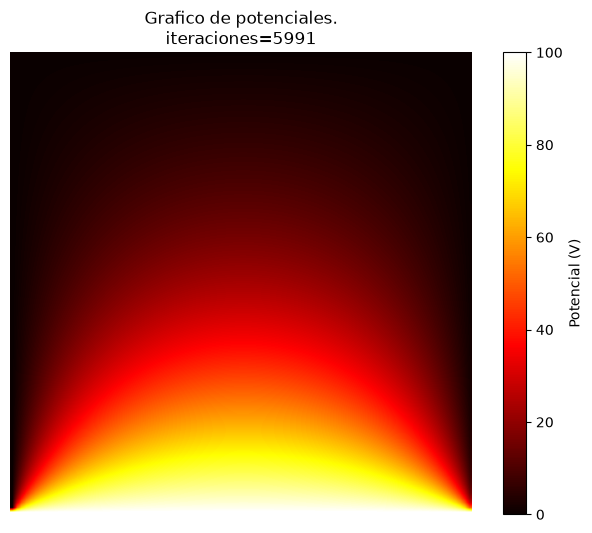

In [7]:
# Grafico de calor 
plt.figure(figsize=(8,6))
plt.imshow(Z, origin='lower', cmap='hot', extent=[0, div, 0, div], interpolation='bilinear')
plt.title(f'Grafico de potenciales.\niteraciones={inte}')
plt.axis('off')
plt.colorbar(label='Potencial (V)')
plt.show()

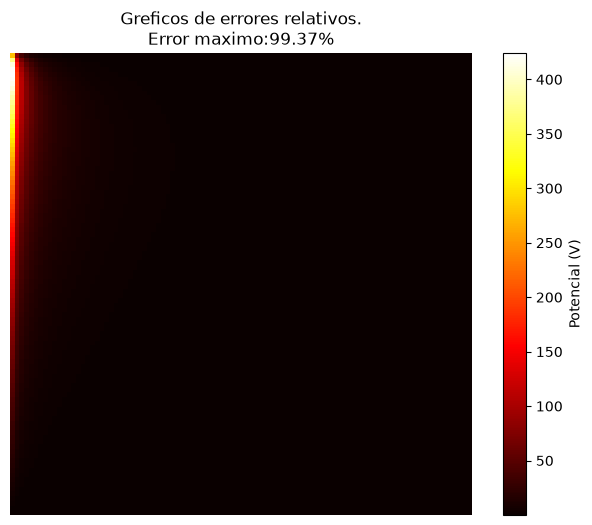

In [20]:
#ejecutamos la solucion analitica para la misma tolerancias para realizar la comparación
z0,_,_,_ = Laplace_analitca2(100, tol, 100 , 100)
eps = 1e-15 # valor auxiliar para evitar divisiones entre cero en el calculo de errores

#eliminamos las fornteras debido a que puede presentar errores debido a la naturaleza ondulatoria de la funcion analitica 
V_fdm_int = V[1:-1, 1:-1]
V_anal_int = z0[1:-1, 1:-1]

#calculo errroesr relativo punto a punto y maximo
err_rel_matriz = np.abs(V_fdm_int - V_anal_int) / (np.abs(V_anal_int) + eps)
err_rel_max = np.max(np.abs(V_fdm_int -V_anal_int)) / np.max(np.abs(V_anal_int)) * 100

#grafica de errores relativos
plt.figure(figsize=(8,6))
plt.imshow(err_rel_matriz, origin='lower', cmap='hot')
plt.title(f'Greficos de errores relativos.\nError maximo:{err_rel_max :.2f}%')
plt.axis('off')
plt.colorbar(label='Potencial (V)')
plt.show()

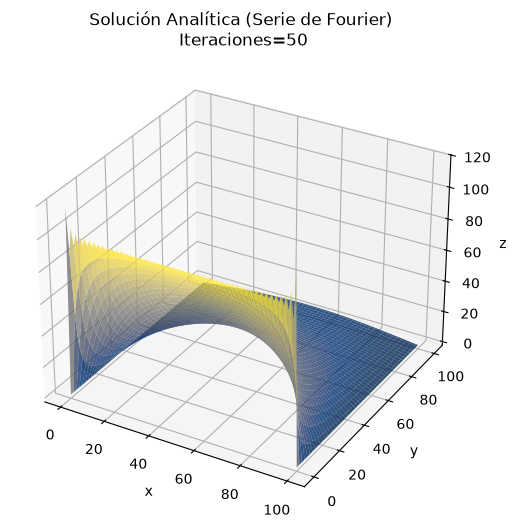

In [ ]:
# Ejecución de la función analitica para la nueva tolerancia
z1, x1, y1 , inte1 = Laplace_analitca2(100, 1e-4, 100,100)

#Grafica de solucion analitica 3D
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x1, y1, z1, cmap='cividis', alpha=0.8)
ax.set_title(f"Solución Analítica (Serie de Fourier)\n Iteraciones={inte1}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


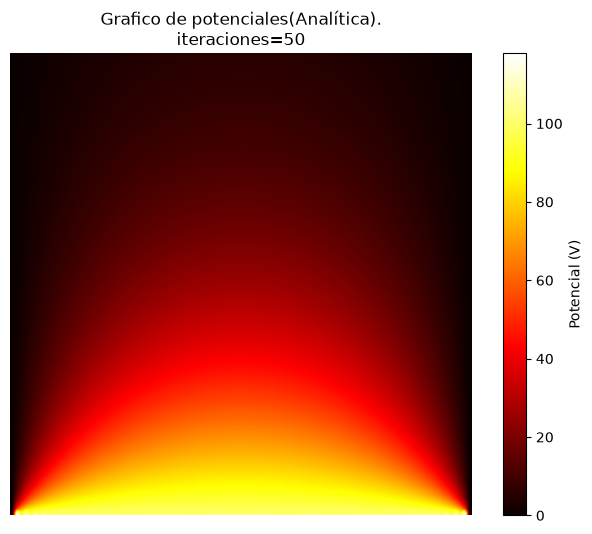

In [23]:
# Grafico de calor 
plt.figure(figsize=(8,6))
plt.imshow(z1, origin='lower', cmap='hot', extent=[0, div, 0, div], interpolation='bilinear')
plt.title(f'Grafico de potenciales(Analítica).\niteraciones={inte1}')
plt.axis('off')
plt.colorbar(label='Potencial (V)')
plt.show()

### Punto 2 ###


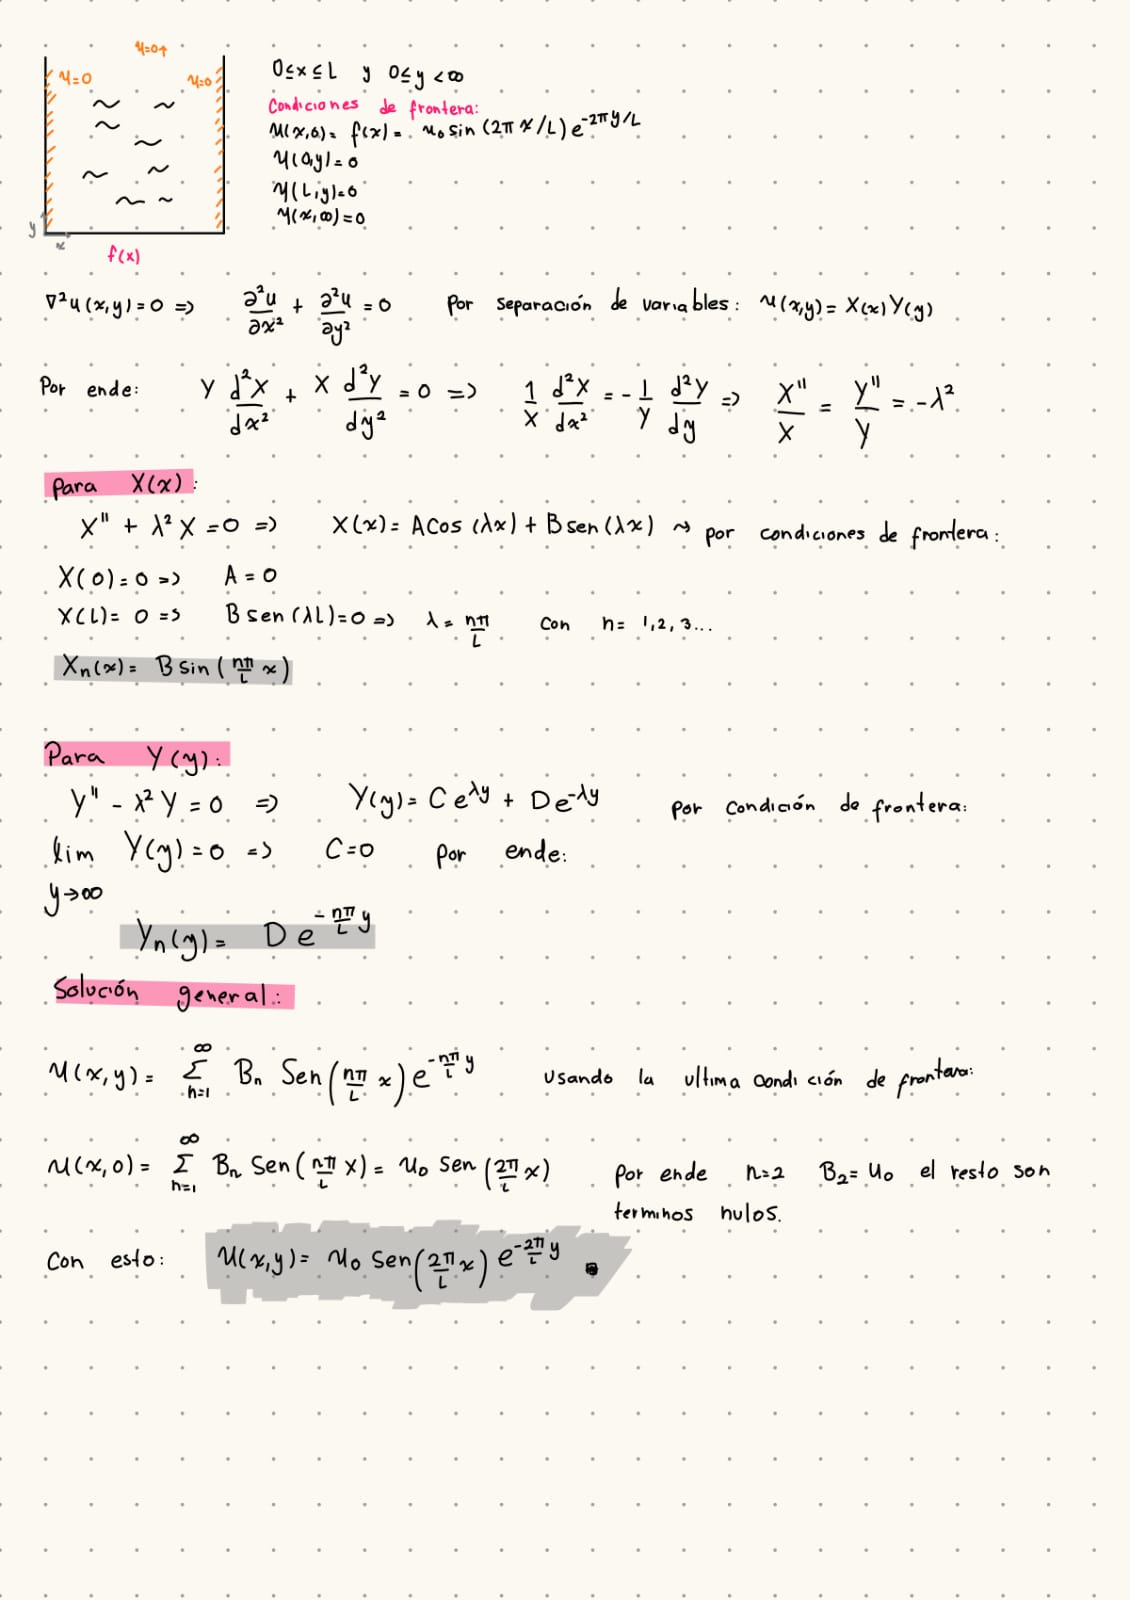


Notemos que para la solución analitica el factor de la coordenada $y$ depende de el termino $e^{\frac{-2\pi y}{L}}$, para solucionar el problema de no poder realizar una malla infinita aprovecharemos este factor y realizaremos una logitud en y de manera tal que los valores del campo en este punto sea muy pequeños, notemos que si tomamos $y =  1.5L$ tendriamos $e^{-3\pi}\approx 8$ x $10^{-5}$, asi que usaremos este factor para el desarrolo de la malla y solucion por diferencias finitas (se podiran usar mayores factores de $L$ pero esto haria mas lentos los calculos a acosta de una diferncia cada vez mas cercana).

In [ ]:
#definicion de fdm para mallas no necesariamente cuadradas con tolerancia
def Laplace_fdmtol2(V0, tol=0.01):  
    Nx = V0.shape[0]
    Ny = V0.shape[1]
    dif = 1.0
    iteraciones = 0
    V1 = V0.copy()

    while dif > tol:
        V = V1.copy()  

        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                V[i, j] = 0.25 * (V1[i + 1, j] + V1[i - 1, j] + V1[i, j + 1] + V1[i, j - 1])

        dif = np.max(np.abs(V - V1))
        iteraciones += 1
        V1 = V

    return V1, iteraciones

In [51]:
# Definimos los parametros 
L = 100
delta = 1 
u0 = 100
nx = int (L / delta)
ny = int (1.5 * L / delta)

#valores auxiliares para calculos y graficas
x = np.linspace(0, L, nx )
y = np.linspace(0, 1.5 * L, ny )
X, Y = np.meshgrid(x, y)

#Creamos la matriz con la informacion inicial 
v_i = np.zeros((ny,nx), float)
v_i[0,:] = u0 * np.sin(2 * np.pi * x /L)


#Ejecutamos la funcion 
v_f , inte = Laplace_fdmtol2(v_i, 1e-5)

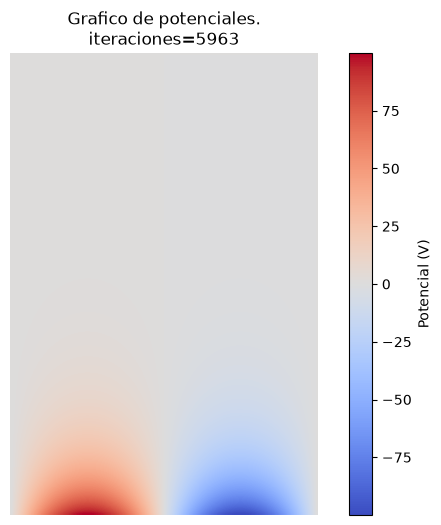

In [52]:
# Grafico de calor 
plt.figure(figsize=(8,6))
plt.imshow(v_f, origin='lower', cmap='coolwarm', extent=[0, nx, 0, ny], interpolation='bilinear')
plt.title(f'Grafico de potenciales.\niteraciones={inte}')
plt.axis('off')
plt.colorbar(label='Potencial (V)')
plt.show()

### Punto 3 ###

In [24]:
#Definimos la nueva funcion de calculo de potencial para placas paralelas de 100V y -100V
def Laplace_fdmtol2(V0, tol=0.01):  
    Nx = V0.shape[0]
    Ny = V0.shape[1]
    dif = 1.0
    iteraciones = 0
    V1 = V0.copy()
    
    placapos = V0 == 100
    placaneg = V0 == -100

    while dif > tol:
        V = V1.copy()  

        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                V[i, j] = 0.25 * (V1[i + 1, j] + V1[i - 1, j] + V1[i, j + 1] + V1[i, j - 1])
                
        V[placapos] = 100
        V[placaneg] = -100           

        dif = np.max(np.abs(V - V1))
        iteraciones += 1
        V1 = V

    return V1, iteraciones

In [33]:
#Creamos el tamaño y la malla con la cual vamos a trabajar
Nx , Ny = 160 , 100
v_0 = np.zeros ((Ny,Nx),float)

#agregamos los puntos que representan las placas 
for i in range (25,76):
    v_0[i,60] = -100
    v_0[i,100] = 100

#ejecutamos la funcion para nuestro caso 
phi , inte2 = Laplace_fdmtol2(v_0,tol)


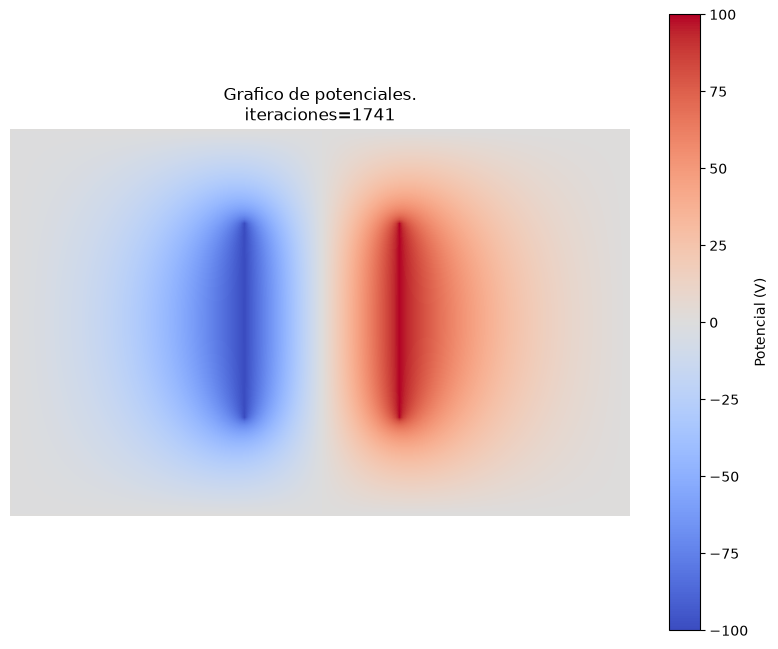

In [34]:
#Grafica de los potenciales
plt.figure(figsize=(10,8))
plt.imshow(phi, origin='lower', cmap='coolwarm', extent=[0, Nx, 0, Ny], interpolation='bilinear')
plt.title(f'Grafico de potenciales.\niteraciones={inte2}')
plt.axis('off')
plt.colorbar(label='Potencial (V)')
plt.show()

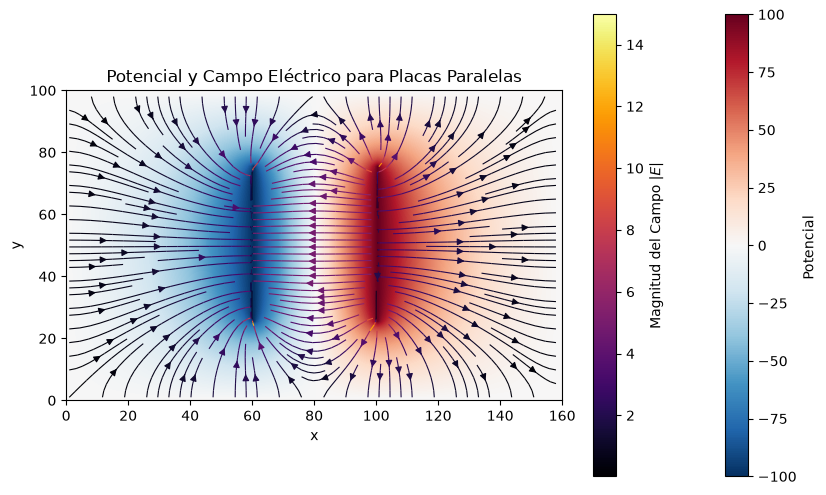

In [36]:
# 4. Cálculo del Campo Eléctrico E = -grad(V)
# Ex representa la derivada respecto a las columnas (eje x)
Ex = -(phi[1:-1, 2:] - phi[1:-1, :-2]) / 2.0

# Ey representa la derivada respecto a las filas (eje y)
Ey = -(phi[2:, 1:-1] - phi[:-2, 1:-1]) / 2.0

# Magnitud del campo eléctrico
magnitude = np.sqrt(Ex**2 + Ey**2)

# Coordenadas internas de la malla
x = np.arange(1, Nx - 1)
y = np.arange(1, Ny - 1)

# 5. Visualización
fig, ax = plt.subplots(figsize=(10, 6))

# Fondo: Potencial eléctrico
im = ax.imshow(phi, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny], interpolation="bilinear")
cbar = fig.colorbar(im, ax=ax, label='Potencial ')

# Líneas de campo eléctrico
strm = ax.streamplot(x, y, Ex, Ey, color=magnitude, cmap='inferno', density=1.5, linewidth=0.8)
fig.colorbar(strm.lines, ax=ax, label='Magnitud del Campo $|E|$')

ax.set_title('Potencial y Campo Eléctrico para Placas Paralelas')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

plt.show()